In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


In [3]:
df=pd.read_csv('heart.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


<Axes: xlabel='age', ylabel='target'>

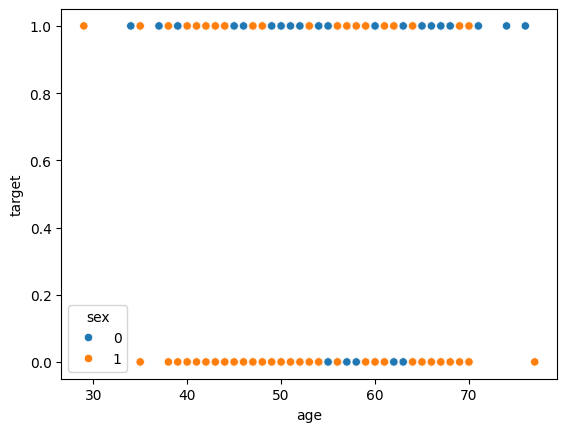

In [4]:
sns.scatterplot(
    data=df,
    x='age',
    y='target',
    hue='sex'
)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


<Axes: xlabel='chol', ylabel='target'>

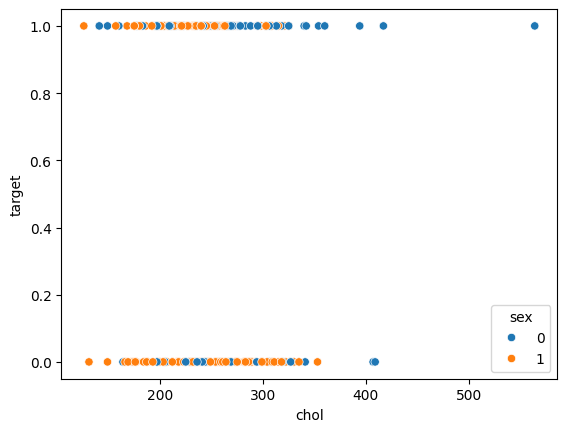

In [6]:
sns.scatterplot(
    data=df,
    x='chol',
    y='target',
    hue='sex'
)


In [7]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [8]:
df['target'].unique()

array([1, 0])

In [9]:
X=df.drop(columns='target',axis=1)
Y=df['target']

In [10]:
X.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2


In [11]:
Y.head()

0    1
1    1
2    1
3    1
4    1
Name: target, dtype: int64

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

In [13]:
model=LogisticRegression(max_iter=1500)
model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1500
,multi_class,'deprecated'


In [14]:
y_preds=model.predict(X_test)

In [15]:
print('Accuracy Score: ',accuracy_score(y_test,y_preds)*100,'%')
print('Precision Score: ',precision_score(y_test,y_preds)*100,'%')
print('recall_score : ',recall_score(y_test,y_preds)*100,'%')
print('f1_score : ',f1_score(y_test,y_preds)*100,'%')

Accuracy Score:  88.52459016393442 %
Precision Score:  87.87878787878788 %
recall_score :  90.625 %
f1_score :  89.23076923076924 %


In [17]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [18]:
model=LogisticRegression(max_iter=1500)
model.fit(X_train,y_train)
y_preds=model.predict(X_test)
print('Accuracy Score: ',accuracy_score(y_test,y_preds)*100,'%')
print('Precision Score: ',precision_score(y_test,y_preds)*100,'%')

Accuracy Score:  85.24590163934425 %
Precision Score:  87.09677419354838 %
